# Explorative Analyse: VR Evacuation + Survey Daten

Dieses Notebook lädt die In-Game-Rohdaten (CSV) und die Survey-/Evac-Time-Daten (Excel),
prüft Datenqualität und erstellt erste Übersichtsplots.

Fokus dieser ersten Runde:
- Datenstruktur verstehen
- Fehlende Werte und Sampling prüfen
- Basisplots für Biomarker und Bewegung
- Survey-Sheets auf Teilnehmer-ID-Mapping prüfen
- Erste Verknüpfung zwischen Spiel- und Surveydaten herstellen

## In-Game Daten laden

In [35]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "scAInce Lab Messungen und survey results"
GAME_DIR = DATA_DIR / "In-Game-Messungen"
EXCEL_PATH = DATA_DIR / "Survey Results and Evac Times.xlsx"

print(f"Arbeitsverzeichnis: {BASE_DIR}")
print(f"Game-Daten-Ordner gefunden: {GAME_DIR.exists()} -> {GAME_DIR}")
print(f"Survey-Excel gefunden: {EXCEL_PATH.exists()} -> {EXCEL_PATH}")


def participant_id_from_path(path: Path) -> int | None:
    match = re.search(r"(\d+)", path.stem)
    return int(match.group(1)) if match else None

Arbeitsverzeichnis: c:\Users\kevin\OneDrive - stud.tu-darmstadt.de\Uni_Master\Master_BauIng_4. Semester\Small and Big Data in der Verkehrstechnik\Übung 1 - scAInce Lab
Game-Daten-Ordner gefunden: True -> c:\Users\kevin\OneDrive - stud.tu-darmstadt.de\Uni_Master\Master_BauIng_4. Semester\Small and Big Data in der Verkehrstechnik\Übung 1 - scAInce Lab\scAInce Lab Messungen und survey results\In-Game-Messungen
Survey-Excel gefunden: True -> c:\Users\kevin\OneDrive - stud.tu-darmstadt.de\Uni_Master\Master_BauIng_4. Semester\Small and Big Data in der Verkehrstechnik\Übung 1 - scAInce Lab\scAInce Lab Messungen und survey results\Survey Results and Evac Times.xlsx


In [36]:
csv_files = sorted(GAME_DIR.glob("*.csv"))
print(f"Anzahl CSV-Dateien: {len(csv_files)}")
print([p.name for p in csv_files])

all_runs = []
for file_path in csv_files:
    df = pd.read_csv(file_path)
    df["participant_id"] = participant_id_from_path(file_path)
    df["source_file"] = file_path.name

    if "Time" in df.columns:
        df["time_td"] = pd.to_timedelta(df["Time"], errors="coerce")

    all_runs.append(df)

game_df = pd.concat(all_runs, ignore_index=True)
print(f"Gesamtzeilen über alle Runs: {len(game_df):,}")
print(f"Anzahl Spalten: {game_df.shape[1]}")

game_df.info()

Anzahl CSV-Dateien: 8
['144.csv', '145.csv', '146.csv', '147.csv', '159.csv', '160.csv', '161.csv', '162.csv']
Gesamtzeilen über alle Runs: 173,784
Anzahl Spalten: 36
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173784 entries, 0 to 173783
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype          
---  ------                           --------------   -----          
 0   Time                             173784 non-null  object         
 1   Headset.Controller.L.Forward.X   0 non-null       float64        
 2   Headset.Controller.L.Forward.Y   0 non-null       float64        
 3   Headset.Controller.L.Forward.Z   0 non-null       float64        
 4   Headset.Controller.L.Position.X  173695 non-null  float64        
 5   Headset.Controller.L.Position.Y  173695 non-null  float64        
 6   Headset.Controller.L.Position.Z  173695 non-null  float64        
 7   Headset.Controller.L.Up.X        0 non-null       float64        
 8   Headset

## Delete empty rows

In [37]:
# Komplett leere Spalten (0 non-null Werte) aus game_df entfernen
empty_cols = game_df.columns[game_df.isna().all()].tolist()

print(f"Entferne {len(empty_cols)} komplett leere Spalten:")
for c in empty_cols:
    print(f"  - {c}")

game_df = game_df.drop(columns=empty_cols)

# HeartRate = 0 ist physiologisch unmöglich (Sensorausfall) -> als fehlend behandeln
hr_zero_mask = game_df["Headset.HeartRate"] == 0
print(f"\nHeartRate: {hr_zero_mask.sum()} Nullwerte durch NaN ersetzt")
print(game_df.loc[hr_zero_mask, "participant_id"].value_counts().to_string())
game_df.loc[hr_zero_mask, "Headset.HeartRate"] = np.nan

print(f"\nVerbleibende Spalten: {game_df.shape[1]}")
game_df.info()
game_df.head()

Entferne 15 komplett leere Spalten:
  - Headset.Controller.L.Forward.X
  - Headset.Controller.L.Forward.Y
  - Headset.Controller.L.Forward.Z
  - Headset.Controller.L.Up.X
  - Headset.Controller.L.Up.Y
  - Headset.Controller.L.Up.Z
  - Headset.Controller.R.Forward.X
  - Headset.Controller.R.Forward.Y
  - Headset.Controller.R.Forward.Z
  - Headset.Controller.R.Up.X
  - Headset.Controller.R.Up.Y
  - Headset.Controller.R.Up.Z
  - Headset.Head.Up.X
  - Headset.Head.Up.Y
  - Headset.Head.Up.Z

HeartRate: 53 Nullwerte durch NaN ersetzt
participant_id
144    53

Verbleibende Spalten: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173784 entries, 0 to 173783
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype          
---  ------                           --------------   -----          
 0   Time                             173784 non-null  object         
 1   Headset.Controller.L.Position.X  173695 non-null  float64        
 2   Headset.Contro

,Time,Headset.Controller.L.Position.X,Headset.Controller.L.Position.Y,Headset.Controller.L.Position.Z,Headset.Controller.R.Position.X,Headset.Controller.R.Position.Y,Headset.Controller.R.Position.Z,Headset.Gaze.X,Headset.Gaze.Y,Headset.Head.Forward.X,Headset.Head.Forward.Y,Headset.Head.Forward.Z,Headset.Head.Position.X,Headset.Head.Position.Y,Headset.Head.Position.Z,Headset.HeartRate,Headset.PupilDilation.L,Headset.PupilDilation.R,participant_id,source_file,time_td
0,00:00:08.366,972.6488,87.39048,-1491.048,972.6488,87.39048,-1491.048,-0.174333,-0.002045,-0.248156,-0.015034,0.968603,972.5994,89.58212,-1490.5,NaN,4.231827,4.275513,144,144.csv,0 days 00:00:08.366000
1,00:00:08.382,972.6494,87.39048,-1491.048,972.6494,87.39048,-1491.048,NaN,NaN,-0.251559,-0.014685,0.967731,972.5995,89.58216,-1490.5,NaN,NaN,NaN,144,144.csv,0 days 00:00:08.382000
2,00:00:08.387,972.6498,87.39048,-1491.048,972.6498,87.39048,-1491.048,-0.161317,0.001099,-0.255297,-0.014637,0.966752,972.5997,89.58237,-1490.5,NaN,4.354782,4.252914,144,144.csv,0 days 00:00:08.387000
3,00:00:08.399,972.6500,87.39048,-1491.048,972.6500,87.39048,-1491.048,-0.155351,0.000702,-0.258277,-0.013798,0.965973,972.5995,89.58244,-1490.5,NaN,4.265991,4.255798,144,144.csv,0 days 00:00:08.399000
4,00:00:08.410,972.6505,87.39048,-1491.048,972.6505,87.39048,-1491.048,-0.141084,-0.009659,-0.261014,-0.013476,0.965241,972.5995,89.58254,-1490.5,NaN,4.275574,4.231003,144,144.csv,0 days 00:00:08.410000


In [38]:
overview_rows = []
for pid, df_pid in game_df.groupby("participant_id", dropna=False):
    time_min = df_pid["time_td"].min() if "time_td" in df_pid else pd.NaT
    time_max = df_pid["time_td"].max() if "time_td" in df_pid else pd.NaT
    duration_s = (time_max - time_min).total_seconds() if pd.notna(time_min) and pd.notna(time_max) else np.nan

    dt_ms = np.nan
    if "time_td" in df_pid.columns:
        dt = df_pid["time_td"].sort_values().diff().dropna().dt.total_seconds() * 1000
        if len(dt) > 0:
            dt_ms = dt.median()

    overview_rows.append(
        {
            "participant_id": pid,
            "rows": len(df_pid),
            "time_start": time_min,
            "time_end": time_max,
            "duration_s": duration_s,
            "median_sensor_interval_ms": dt_ms,
        }
    )

overview_df = pd.DataFrame(overview_rows).sort_values("participant_id")
overview_df

,participant_id,rows,time_start,time_end,duration_s,median_sensor_interval_ms
0,144,24299,0 days 00:00:08.366000,0 days 00:04:38.523000,270.157,11.0
1,145,21633,0 days 00:00:08.770000,0 days 00:04:08.920000,240.150,11.0
2,146,22527,0 days 00:00:09.959000,0 days 00:04:20.103000,250.144,11.0
3,147,11708,0 days 00:00:12.897000,0 days 00:02:22.967000,130.070,11.0
4,159,23396,0 days 00:01:12.232000,0 days 00:05:32.366000,260.134,11.0
5,160,24305,0 days 00:00:18.536000,0 days 00:04:48.665000,270.129,11.0
6,161,28809,0 days 00:00:11.223000,0 days 00:05:31.384000,320.161,11.0
7,162,17107,0 days 00:00:07.030000,0 days 00:03:17.143000,190.113,11.0


In [39]:
biomarker_cols = ["Headset.HeartRate", "Headset.PupilDilation.L", "Headset.PupilDilation.R"]
available_cols = [c for c in biomarker_cols if c in game_df.columns]

avail_rows = []
for pid, df_pid in game_df.groupby("participant_id"):
    row = {"participant_id": pid}
    for col in available_cols:
        n = df_pid[col].notna().sum()
        row[col] = f"{n:,} rows" if n > 0 else "—"
    avail_rows.append(row)

avail_df = pd.DataFrame(avail_rows).sort_values("participant_id").reset_index(drop=True)
avail_df.columns = ["participant_id"] + [c.replace("Headset.", "") for c in available_cols]
avail_df

,participant_id,HeartRate,PupilDilation.L,PupilDilation.R
0,144,—,"24,232 rows","24,232 rows"
1,145,47 rows,"21,558 rows","21,558 rows"
2,146,49 rows,"22,421 rows","22,421 rows"
3,147,25 rows,"11,676 rows","11,676 rows"
4,159,—,—,—
5,160,—,—,—
6,161,—,—,—
7,162,—,—,—


## Survey-Daten laden

In [40]:
sheet_dict = pd.read_excel(EXCEL_PATH, sheet_name=None)


def find_id_column(columns: list[str]) -> str | None:
    patterns = [
        "participation",
        "participant",
        "teilnehmer",
        "proband",
        "subject",
        "code",
        "vp",
        "id",
    ]
    for c in columns:
        cl = str(c).strip().lower()
        if any(p in cl for p in patterns):
            return c
    return None

survey_frames = []
for sheet_name, df in sheet_dict.items():
    df_local = df.copy()
    id_col = find_id_column(list(df_local.columns))
    df_local["participant_id"] = pd.to_numeric(df_local[id_col], errors="coerce")
    df_local = df_local[df_local["participant_id"].notna()].copy()
    df_local["participant_id"] = df_local["participant_id"].astype(int)
    df_local["sheet_name"] = sheet_name
    survey_frames.append(df_local)

map_candidates = []
for sheet_name, df in sheet_dict.items():
    cols = [c for c in df.columns if any(k in str(c).lower() for k in ["map", "karte", "kartentyp", "2d", "3d"])]
    if not cols:
        continue
    temp = df.copy()
    id_col = find_id_column(list(temp.columns))
    temp["participant_id"] = pd.to_numeric(temp[id_col], errors="coerce")
    temp = temp[temp["participant_id"].notna()].copy()
    temp["participant_id"] = temp["participant_id"].astype(int)
    subset = temp[["participant_id"] + cols].copy()
    subset["sheet_name"] = sheet_name
    map_candidates.append(subset)

map_info_df = pd.concat(map_candidates, ignore_index=True)
map_info_159 = map_info_df[map_info_df["participant_id"] == 159]

print("Kartentyp-bezogene Spalten über alle Sheets:")
map_info_df.head(20)

Kartentyp-bezogene Spalten über alle Sheets:


,participant_id,Map type,2D gam exp,3D gam exp,2D map exp,3D map exp,2D evac eff (if map type 2D),3D comp (if map type 2D),3D evac eff (if map type 3D),2D comp (if map type 3D),sheet_name
0,144,2D,1,3,4,2,3.0,4.0,NaN,NaN,Tabelle1
1,145,2D,4,3,4,2,5.0,3.0,NaN,NaN,Tabelle1
2,146,3D,5,3,2,4,NaN,NaN,5.0,2.0,Tabelle1
3,147,3D,2,4,4,3,NaN,NaN,4.0,2.0,Tabelle1
4,159,2D,3,3,5,3,5.0,3.0,NaN,NaN,Tabelle1
5,161,3D,3,4,4,4,NaN,NaN,4.0,2.0,Tabelle1
6,160,2D,3,1,4,1,5.0,1.0,NaN,NaN,Tabelle1
7,162,3D,3,1,2,1,NaN,NaN,4.0,3.0,Tabelle1


## Datenanalyse und Visualisierung

In [41]:
# Biomarker-Aggregation pro Teilnehmer
bio_agg = (
    game_df
    .groupby("participant_id")
    .agg(
        heart_rate_mean=("Headset.HeartRate", "mean"),
        pupil_dilation_L_mean=("Headset.PupilDilation.L", "mean"),
        pupil_dilation_R_mean=("Headset.PupilDilation.R", "mean"),
    )
    .reset_index()
)

# Evakuierungszeit parsen (Excel-Format MM:SS:00)
def parse_evac_time(t):
    if pd.isna(t):
        return np.nan
    parts = str(t).split(":")
    if len(parts) >= 2:
        return int(parts[0]) * 60 + int(parts[1])
    return np.nan

survey_main = sheet_dict["Tabelle1"].copy()
survey_main = survey_main.rename(columns={"Participation Code": "participant_id"})
survey_main["participant_id"] = pd.to_numeric(survey_main["participant_id"], errors="coerce")
survey_main = survey_main[survey_main["participant_id"].notna()].copy()
survey_main["participant_id"] = survey_main["participant_id"].astype(int)
survey_main["evac_time_s"] = survey_main["Evac time [m:s]"].apply(parse_evac_time)

drop_cols = ["Unnamed: 10", "Unnamed: 13", "Notes", "Experience", "Other comments", "Evac time [m:s]"]
merged_overview = (
    overview_df
    .merge(bio_agg, on="participant_id", how="left")
    .merge(survey_main.drop(columns=drop_cols, errors="ignore"), on="participant_id", how="left")
)
merged_overview

,participant_id,rows,time_start,time_end,duration_s,median_sensor_interval_ms,heart_rate_mean,pupil_dilation_L_mean,pupil_dilation_R_mean,Map type,Gender,Age,VR experience,2D gam exp,3D gam exp,2D map exp,3D map exp,FFM fam,2D evac eff (if map type 2D),3D comp (if map type 2D),3D evac eff (if map type 3D),2D comp (if map type 3D),evac_time_s
0,144,24299,0 days 00:00:08.366000,0 days 00:04:38.523000,270.157,11.0,NaN,4.410363,4.409051,2D,m,24,y,1,3,4,2,4,3.0,4.0,NaN,NaN,275
1,145,21633,0 days 00:00:08.770000,0 days 00:04:08.920000,240.150,11.0,124.936170,5.341616,5.213278,2D,m,30,n,4,3,4,2,1,5.0,3.0,NaN,NaN,248
2,146,22527,0 days 00:00:09.959000,0 days 00:04:20.103000,250.144,11.0,108.428571,4.512642,4.322358,3D,f,25,n,5,3,2,4,4,NaN,NaN,5.0,2.0,257
3,147,11708,0 days 00:00:12.897000,0 days 00:02:22.967000,130.070,11.0,101.560000,3.959627,4.066474,3D,m,32,y,2,4,4,3,3,NaN,NaN,4.0,2.0,142
4,159,23396,0 days 00:01:12.232000,0 days 00:05:32.366000,260.134,11.0,NaN,NaN,NaN,2D,m,24,y,3,3,5,3,2,5.0,3.0,NaN,NaN,332
5,160,24305,0 days 00:00:18.536000,0 days 00:04:48.665000,270.129,11.0,NaN,NaN,NaN,2D,f,28,n,3,1,4,1,1,5.0,1.0,NaN,NaN,288
6,161,28809,0 days 00:00:11.223000,0 days 00:05:31.384000,320.161,11.0,NaN,NaN,NaN,3D,m,30,n,3,4,4,4,1,NaN,NaN,4.0,2.0,331
7,162,17107,0 days 00:00:07.030000,0 days 00:03:17.143000,190.113,11.0,NaN,NaN,NaN,3D,m,28,n,3,1,2,1,1,NaN,NaN,4.0,3.0,197


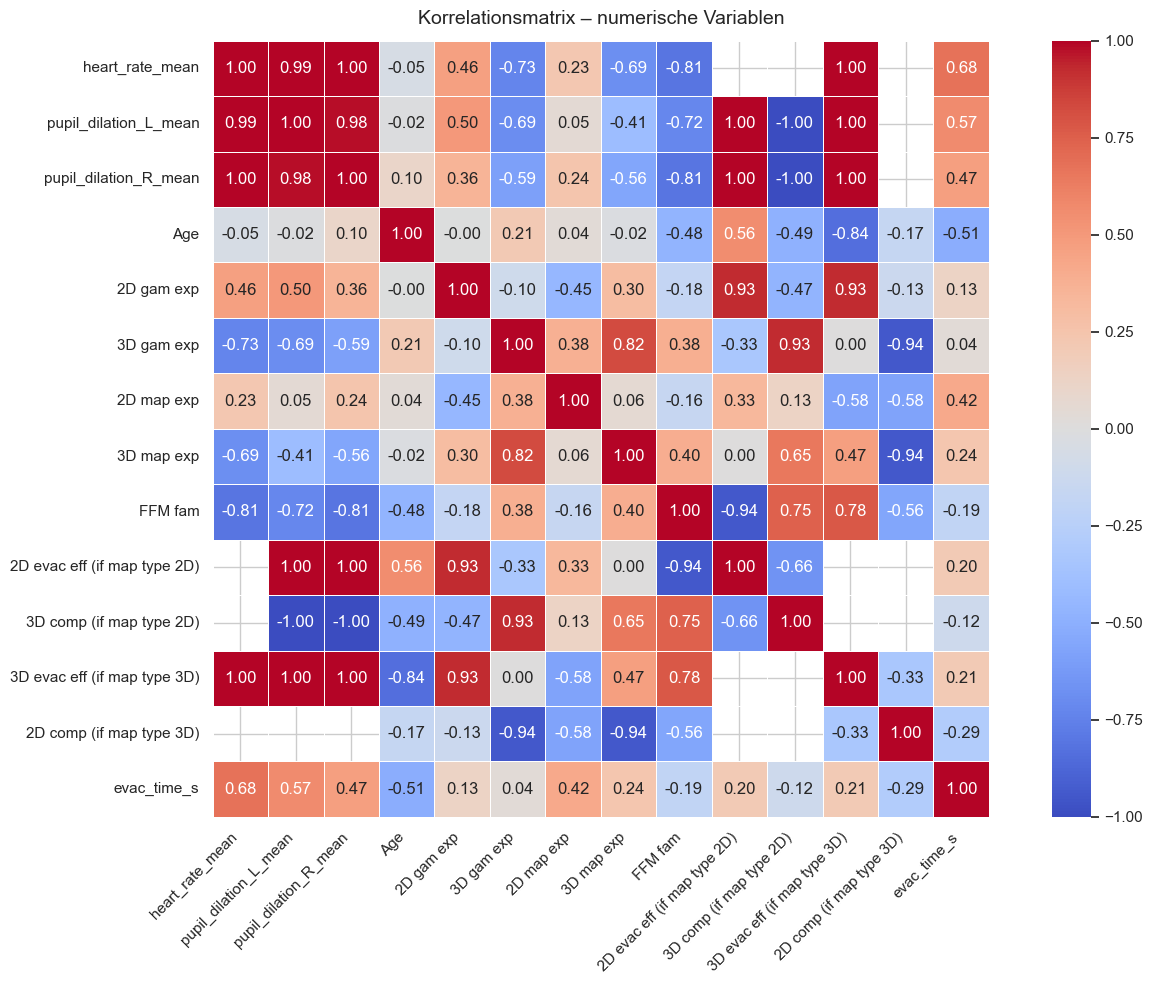

,heart_rate_mean,pupil_dilation_L_mean,pupil_dilation_R_mean,Age,2D gam exp,3D gam exp,2D map exp,3D map exp,FFM fam,2D evac eff (if map type 2D),3D comp (if map type 2D),3D evac eff (if map type 3D),2D comp (if map type 3D),evac_time_s
heart_rate_mean,1.000000,0.992935,0.997135,-4.730077e-02,4.617862e-01,-7.266830e-01,0.231595,-6.869730e-01,-0.811924,NaN,NaN,1.000000e+00,NaN,0.676546
pupil_dilation_L_mean,0.992935,1.000000,0.980612,-1.521479e-02,5.027312e-01,-6.901047e-01,0.050239,-4.128684e-01,-0.720072,1.000000e+00,-1.000000,1.000000e+00,NaN,0.567342
pupil_dilation_R_mean,0.997135,0.980612,1.000000,1.031124e-01,3.586834e-01,-5.870595e-01,0.242770,-5.601464e-01,-0.806386,1.000000e+00,-1.000000,1.000000e+00,NaN,0.471525
Age,-0.047301,-0.015215,0.103112,1.000000e+00,-7.028534e-17,2.131238e-01,0.039014,-1.978356e-02,-0.475114,5.555556e-01,-0.485662,-8.372184e-01,-0.167444,-0.509587
2D gam exp,0.461786,0.502731,0.358683,-7.028534e-17,1.000000e+00,-1.025978e-01,-0.450749,3.000000e-01,-0.176261,9.271726e-01,-0.473684,9.271726e-01,-0.132453,0.129391
3D gam exp,-0.726683,-0.690105,-0.587060,2.131238e-01,-1.025978e-01,1.000000e+00,0.375748,8.207827e-01,0.384285,-3.333333e-01,0.927173,5.233642e-17,-0.942809,0.038878
2D map exp,0.231595,0.050239,0.242770,3.901372e-02,-4.507489e-01,3.757477e-01,1.000000,5.634362e-02,-0.161382,3.333333e-01,0.132453,-5.773503e-01,-0.577350,0.417114
3D map exp,-0.686973,-0.412868,-0.560146,-1.978356e-02,3.000000e-01,8.207827e-01,0.056344,1.000000e+00,0.396587,9.064933e-17,0.648886,4.714045e-01,-0.942809,0.240298
FFM fam,-0.811924,-0.720072,-0.806386,-4.751136e-01,-1.762611e-01,3.842851e-01,-0.161382,3.965874e-01,1.000000,-9.428090e-01,0.749269,7.777778e-01,-0.555556,-0.190191
2D evac eff (if map type 2D),NaN,1.000000,1.000000,5.555556e-01,9.271726e-01,-3.333333e-01,0.333333,9.064933e-17,-0.942809,1.000000e+00,-0.662266,NaN,NaN,0.204491


In [42]:
# Korrelationsmatrix aller numerischen Variablen
exclude_from_corr = {"participant_id", "rows", "median_sensor_interval_ms", "time_start", "time_end", "duration_s"}
corr_cols = [
    c for c in merged_overview.select_dtypes(include="number").columns
    if c not in exclude_from_corr
]

corr_matrix = merged_overview[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Korrelationsmatrix – numerische Variablen", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_matrix

<>:5: SyntaxWarning: invalid escape sequence '\?'
<>:5: SyntaxWarning: invalid escape sequence '\?'
C:\Users\kevin\AppData\Local\Temp\ipykernel_12412\3326134464.py:5: SyntaxWarning: invalid escape sequence '\?'
  analysis_df["map_type_uncertain"] = analysis_df["map_type_raw"].str.contains("\?", regex=True, na=False)


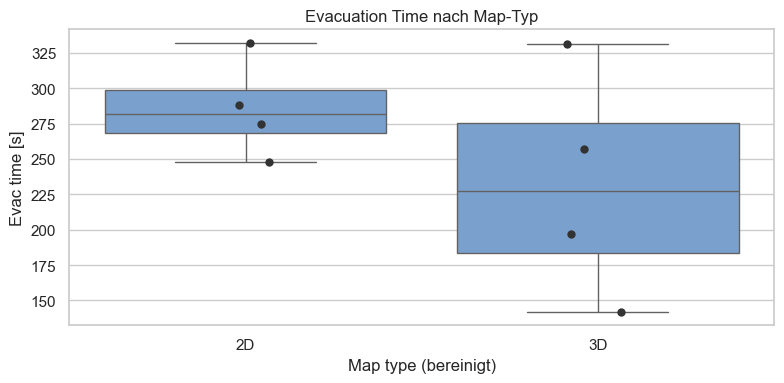

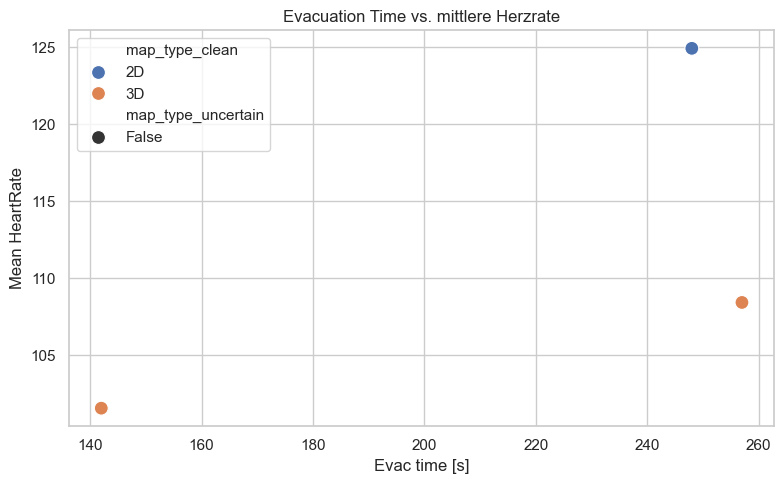

In [44]:
analysis_df = merged_overview.copy()
if "Map type" in analysis_df.columns:
    analysis_df["map_type_raw"] = analysis_df["Map type"].astype(str).str.strip()
    analysis_df["map_type_clean"] = analysis_df["map_type_raw"].str.replace("?", "", regex=False).str.upper()
    analysis_df["map_type_uncertain"] = analysis_df["map_type_raw"].str.contains("\?", regex=True, na=False)

box_df = pd.DataFrame()
if {"map_type_clean", "evac_time_s"}.issubset(analysis_df.columns):
    box_df = analysis_df[["map_type_clean", "evac_time_s"]].dropna()

if not box_df.empty and box_df["map_type_clean"].nunique() >= 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=box_df, x="map_type_clean", y="evac_time_s", ax=ax, color="#6ca0dc")
    sns.stripplot(data=box_df, x="map_type_clean", y="evac_time_s", ax=ax, color="#333333", size=6)
    ax.set_title("Evacuation Time nach Map-Typ")
    ax.set_xlabel("Map type (bereinigt)")
    ax.set_ylabel("Evac time [s]")
    plt.tight_layout()
    plt.show()
else:
    print("Zu wenige valide Werte für Boxplot map_type_clean vs evac_time_s.")

scatter_df = pd.DataFrame()
if {"evac_time_s", "heart_rate_mean", "map_type_clean"}.issubset(analysis_df.columns):
    scatter_df = analysis_df[["evac_time_s", "heart_rate_mean", "map_type_clean", "map_type_uncertain"]].dropna(subset=["evac_time_s", "heart_rate_mean", "map_type_clean"])

if not scatter_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(
        data=scatter_df,
        x="evac_time_s",
        y="heart_rate_mean",
        hue="map_type_clean",
        style="map_type_uncertain",
        s=100,
        ax=ax,
    )
    ax.set_title("Evacuation Time vs. mittlere Herzrate")
    ax.set_xlabel("Evac time [s]")
    ax.set_ylabel("Mean HeartRate")
    plt.tight_layout()
    plt.show()

## Hypothesentests (Mann-Whitney-U-Test)

Der **Mann-Whitney-U-Test** (Wilcoxon-Rangsummentest) ist ein nicht-parametrischer Test, der prüft, ob sich zwei **unabhängige Gruppen** in ihrer zentralen Tendenz unterscheiden. Er setzt keine Normalverteilung voraus und ist daher für die kleine Stichprobe (n = 8) dieses Experiments geeignet.

Es werden zwei Tests **getrennt voneinander** durchgeführt (jeweils mit eigenen Hypothesen H0 & H1). Signifikanzniveau: **α = 0.05** (zweiseitig).

### Test 1: Kartentyp → Evakuierungszeit

- **H0:** mean2D = mean3D (die durchschnittliche Evakuierungszeit unterscheidet sich nicht signifikant durch den Kartentyp)
- **H1:** mean2D ≠ mean3D (die durchschnittliche Evakuierungszeit unterscheidet sich signifikant durch den Kartentyp)

In [46]:
from scipy.stats import mannwhitneyu

alpha = 0.05

# =====================================================================
# Hypothese 1: Kartentyp (2D vs. 3D)  ->  Evakuierungszeit
# =====================================================================
test1_df = analysis_df[["participant_id", "map_type_clean", "evac_time_s"]].dropna()

grp_2d = test1_df.loc[test1_df["map_type_clean"] == "2D", "evac_time_s"]
grp_3d = test1_df.loc[test1_df["map_type_clean"] == "3D", "evac_time_s"]

print("Hypothese 1: Kartentyp -> Evakuierungszeit")
print(f"  Gruppengroessen:  2D = {len(grp_2d)}  |  3D = {len(grp_3d)}")
print(f"  Median Evac-Zeit:  2D = {grp_2d.median():.1f} s  |  3D = {grp_3d.median():.1f} s")
print(f"  Mittelwert:        2D = {grp_2d.mean():.1f} s  |  3D = {grp_3d.mean():.1f} s")

u1, p1 = mannwhitneyu(grp_2d, grp_3d, alternative="two-sided")
print(f"\n  Mann-Whitney U = {u1:.1f},  p = {p1:.4f}")
if p1 < alpha:
    print(f"  => p < {alpha}: H0 verworfen - Kartentyp hat einen signifikanten Einfluss auf die Evac-Zeit.")
else:
    print(f"  => p >= {alpha}: H0 wird beibehalten - kein signifikanter Einfluss nachweisbar.")

Hypothese 1: Kartentyp -> Evakuierungszeit
  Gruppengroessen:  2D = 4  |  3D = 4
  Median Evac-Zeit:  2D = 281.5 s  |  3D = 227.0 s
  Mittelwert:        2D = 285.8 s  |  3D = 231.8 s

  Mann-Whitney U = 12.0,  p = 0.3429
  => p >= 0.05: H0 wird beibehalten - kein signifikanter Einfluss nachweisbar.


### Test 2: Pupillendilatation → Evakuierungszeit

Die (kontinuierliche) Pupillendilatation wird per Median-Split in eine Gruppe mit **niedriger** und eine mit **hoher** Dilatation geteilt.

- **H0:** mean_niedrig = mean_hoch (die durchschnittliche Evakuierungszeit unterscheidet sich nicht signifikant durch die Pupillendilatation)
- **H1:** mean_niedrig ≠ mean_hoch (die durchschnittliche Evakuierungszeit unterscheidet sich signifikant durch die Pupillendilatation)

In [47]:
# =====================================================================
# Hypothese 2: Pupillendilatation  ->  Evakuierungszeit
# =====================================================================
# Der U-Test vergleicht zwei Gruppen. Da die Pupillendilatation eine
# kontinuierliche Groesse ist, teilen wir die Teilnehmer per Median-Split
# in "niedrig" und "hoch" auf und vergleichen deren Evakuierungszeiten.
test2_df = analysis_df.copy()
test2_df["pupil_mean"] = test2_df[["pupil_dilation_L_mean", "pupil_dilation_R_mean"]].mean(axis=1)
test2_df = test2_df[["participant_id", "pupil_mean", "evac_time_s"]].dropna()

pupil_median = test2_df["pupil_mean"].median()
test2_df["pupil_group"] = np.where(test2_df["pupil_mean"] >= pupil_median, "hoch", "niedrig")

print("Hypothese 2: Pupillendilatation -> Evakuierungszeit")
print(f"  Teilnehmer mit Pupillendaten: {len(test2_df)}  (Median-Split bei {pupil_median:.3f})\n")
print(test2_df.sort_values("pupil_mean").to_string(index=False))

grp_low  = test2_df.loc[test2_df["pupil_group"] == "niedrig", "evac_time_s"]
grp_high = test2_df.loc[test2_df["pupil_group"] == "hoch",    "evac_time_s"]

u2, p2 = mannwhitneyu(grp_low, grp_high, alternative="two-sided")
print(f"\n  Gruppengroessen: niedrig = {len(grp_low)}  |  hoch = {len(grp_high)}")
print(f"  Mann-Whitney U = {u2:.1f},  p = {p2:.4f}")
if p2 < alpha:
    print(f"  => p < {alpha}: H0 verworfen - Pupillendilatation haengt mit der Evac-Zeit zusammen.")
else:
    print(f"  => p >= {alpha}: H0 wird beibehalten - kein signifikanter Zusammenhang nachweisbar.")

Hypothese 2: Pupillendilatation -> Evakuierungszeit
  Teilnehmer mit Pupillendaten: 4  (Median-Split bei 4.414)

 participant_id  pupil_mean  evac_time_s pupil_group
            147    4.013051          142     niedrig
            144    4.409707          275     niedrig
            146    4.417500          257        hoch
            145    5.277447          248        hoch

  Gruppengroessen: niedrig = 2  |  hoch = 2
  Mann-Whitney U = 2.0,  p = 1.0000
  => p >= 0.05: H0 wird beibehalten - kein signifikanter Zusammenhang nachweisbar.


### Interpretation der Testergebnisse

| Hypothese | Vergleich | n | U | p | Ergebnis (α = 0.05) |
|-----------|-----------|---|-----|-------|---------------------|
| H1 | Kartentyp 2D vs. 3D → Evac-Zeit | 4 vs. 4 | 12.0 | 0.343 | nicht signifikant |
| H2 | Pupille niedrig vs. hoch → Evac-Zeit | 2 vs. 2 | 2.0 | 1.000 | nicht signifikant |

**Fazit:** In beiden Fällen kann die Nullhypothese nicht verworfen werden – es lässt sich kein statistisch signifikanter Einfluss nachweisen. Deskriptiv evakuieren die 3D-Gruppe (Median 227 s) etwas schneller als die 2D-Gruppe (Median 281.5 s), der Unterschied ist aber nicht signifikant.

**Wichtige Einschränkung (Stichprobengröße):** Die Fallzahlen sind sehr klein. Bei H2 liegen nur für 4 Teilnehmer Pupillendaten vor (2 vs. 2 nach Median-Split); der kleinste mit dem U-Test überhaupt erreichbare zweiseitige p-Wert beträgt hier ≈ 0.33 – ein signifikantes Ergebnis ist somit rechnerisch unmöglich. Die Tests sind daher eher eine methodische Übung als ein belastbarer Nachweis. Für einen kontinuierlichen Prädiktor wie die Pupillendilatation wäre zudem eine Rangkorrelation (Spearman) methodisch passender.